# 📊 Resumo Executivo: Diagnóstico de Retenção e Mudança de Estratégia

## 1. O Pivot do Projeto: De "Churn" para "Propensão"
A análise inicial dos dados revelou uma realidade estrutural crítica do marketplace Olist:
* **A Realidade dos 97%:** Aproximadamente 97% da base de clientes realiza apenas uma compra (Churn Natural). Modelar a "saída" seria ineficiente, pois ela é o padrão.
* **A Nova Estratégia:** O projeto pivotou de *Churn Prediction* para **Repurchase Propensity (Propensão à Recompra)**.
* **O Objetivo:** Identificar padrões latentes nos **~3% de clientes recorrentes** para prever quais novos clientes têm potencial de se tornarem fiéis, permitindo ações de marketing cirúrgicas (Uplift Modeling).

---

## 2. Definição do Alvo (Target)
Baseado na análise de ciclo de vida (*Time-to-Event*) dos clientes recorrentes:
* **Mediana de Retorno:** ~29 dias.
* **Janela de Oportunidade:** A cauda de retorno se estende, mas a janela crítica foi definida em **90 Dias**.
* **Regra do Modelo:**
    * `1 (Ouro)`: Cliente que realizou uma nova compra em até 90 dias após o corte.
    * `0 (Silêncio)`: Cliente que permaneceu inativo nesta janela.

---

## 3. Os 4 Pilares de Influência (Achados da EDA)

Nossa Análise Diagnóstica quebrou mitos e revelou os reais *drivers* de fidelidade:

### 🌍 A. A "Loteria do CEP" (Geografia)
* **O Mito:** "Comprar de vendedor do mesmo estado fideliza mais." -> **REFUTADO**.
    * A taxa de recompra é estatisticamente idêntica para rotas locais vs. interestaduais.
* **A Realidade:** O estado do **Cliente** é o fator determinante.
    * *Alta Fidelidade:* PR, BA, SE (Malha logística eficiente ou força da marca local).
    * *Zona de Risco:* AP, RR, PA (Logística complexa gera experiência traumática e churn imediato).

### 📦 B. Perfil do Vendedor (Seller)
* **Tamanho Importa:** Clientes que compram sua primeira vez com **Vendedores Grandes ("Pro")** têm uma taxa de retenção **~25% maior** do que aqueles que compram de Amadores.
* **Fidelidade à Plataforma:** 71% dos clientes que voltam compram de um **vendedor diferente** do original. O cliente é fiel à Olist, não ao lojista.

### ⭐ C. Matriz de Produtos (Quadrantes)
Nem toda baixa recompra é ruim. Classificamos os produtos em 4 quadrantes para orientar o modelo:
* **Estrelas (Recompra Alta/Nota Alta):** Beleza, Pet Shop, Alimentos.
* **Bens Duráveis (Recompra Baixa/Nota Alta):** Móveis, Eletros (Não são churn, apenas ciclo longo).
* **Risco Real (Recompra Baixa/Nota Baixa):** Móveis de Escritório, Telefonia Fixa (Insatisfação gera churn).

### 🚚 D. Fricção Logística
* **Frete:** O peso do frete no bolso (*Freight Ratio*) **NÃO** diferencia quem sai de quem fica. O cliente fiel aceita o custo do frete tanto quanto o que desiste.
* **Atraso:** O atraso na entrega é um ofensor crítico, especialmente em compras de baixo valor onde a tolerância é menor.

---
*Este notebook detalha a exploração de dados que fundamentou estas conclusões e preparou o terreno para a Engenharia de Features.*

# Carregando os dados

In [68]:
import pandas as pd

df_customer = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_customers_dataset.csv")
df_orders = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_orders_dataset.csv")

In [69]:
df_costumer_orders = pd.merge(df_customer, df_orders, on="customer_id", how="inner")
display(df_costumer_orders)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00


# EDA

## Qual a % de clientes com mais de 1 pedido?

Total de Clientes Únicos: 96096
Clientes com > 1 compra: 2997
Taxa de Recorrência: 3.12%


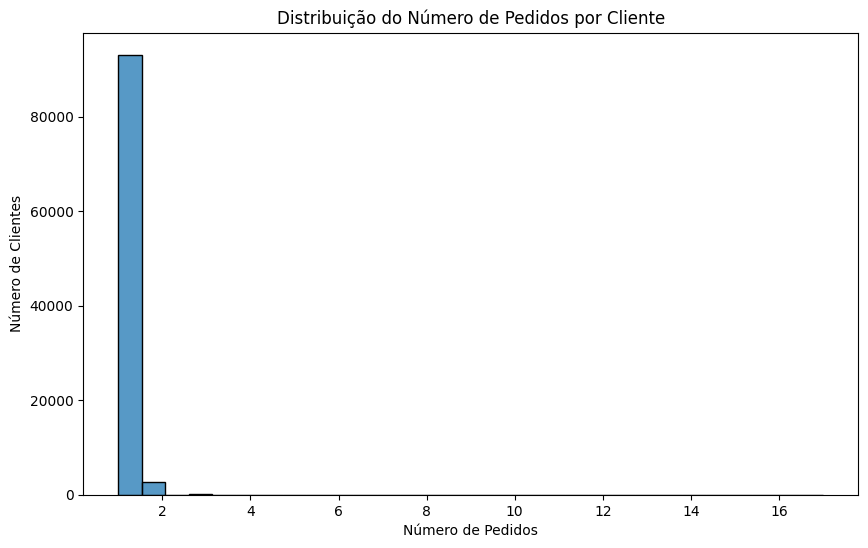

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

pedidos_por_cliente = df_costumer_orders.groupby("customer_unique_id")["order_id"].nunique().reset_index()
pedidos_por_cliente.columns = ["customer_unique_id", "num_pedidos"]

total_clientes = pedidos_por_cliente.shape[0]
clientes_recorrentes = pedidos_por_cliente[pedidos_por_cliente['num_pedidos'] > 1].shape[0]
taxa_recorrencia = (clientes_recorrentes / total_clientes) * 100

print(f"Total de Clientes Únicos: {total_clientes}")
print(f"Clientes com > 1 compra: {clientes_recorrentes}")
print(f"Taxa de Recorrência: {taxa_recorrencia:.2f}%")

plt.figure(figsize=(10, 6))
sns.histplot(pedidos_por_cliente['num_pedidos'], bins=30, kde=False)
plt.title('Distribuição do Número de Pedidos por Cliente')
plt.xlabel('Número de Pedidos')
plt.ylabel('Número de Clientes')
plt.show()

## Qual a frequencia media de compra dos usuarios que realizaram mais de um pedido?

Tempo médio entre compras: 78.8 dias
Mediana de tempo entre compras: 29.0 dias


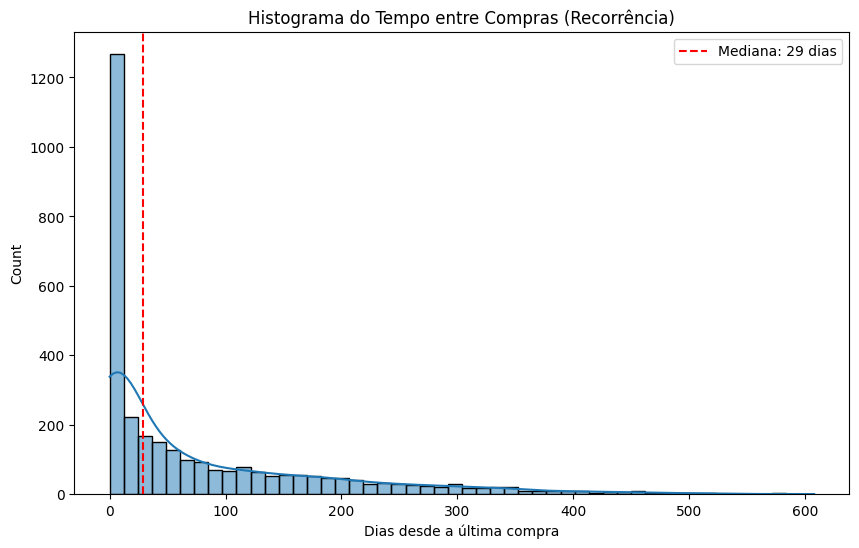

In [71]:
df_costumer_orders['order_purchase_timestamp'] = pd.to_datetime(df_costumer_orders['order_purchase_timestamp'])
df_validado = df_costumer_orders[df_costumer_orders['order_status'] == 'delivered'].copy()

ids_recorrentes = pedidos_por_cliente[pedidos_por_cliente['num_pedidos'] > 1]['customer_unique_id'].tolist()
df_recorrentes = df_validado[df_validado['customer_unique_id'].isin(ids_recorrentes)]

df_recorrentes = df_recorrentes.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

df_recorrentes['data_anterior'] =  df_recorrentes.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
df_recorrentes['dias_entre_pedidos'] = (df_recorrentes['order_purchase_timestamp'] - df_recorrentes['data_anterior']).dt.days

frequencia_media = df_recorrentes['dias_entre_pedidos'].dropna().mean()
mediana_frequencia = df_recorrentes['dias_entre_pedidos'].dropna().median()

print(f"Tempo médio entre compras: {frequencia_media:.1f} dias")
print(f"Mediana de tempo entre compras: {mediana_frequencia:.1f} dias")

# Visualização da Frequência
plt.figure(figsize=(10, 6))
sns.histplot(df_recorrentes['dias_entre_pedidos'].dropna(), bins=50, kde=True)
plt.axvline(mediana_frequencia, color='r', linestyle='--', label=f'Mediana: {mediana_frequencia:.0f} dias')
plt.title("Histograma do Tempo entre Compras (Recorrência)")
plt.xlabel("Dias desde a última compra")
plt.legend()
plt.show()

### Percentis para classificar time to event do churn

In [72]:
# No seu DataFrame de clientes recorrentes (apenas os que compraram > 1 vez)
# Calcule os percentis da coluna 'dias_entre_compras'
import numpy as np

p50 = df_recorrentes['dias_entre_pedidos'].median()
p90 = df_recorrentes['dias_entre_pedidos'].quantile(0.90)
p95 = df_recorrentes['dias_entre_pedidos'].quantile(0.95)

print(f"50% voltam em até: {p50:.1f} dias")
print(f"90% voltam em até: {p90:.1f} dias")
print(f"95% voltam em até: {p95:.1f} dias")

50% voltam em até: 29.0 dias
90% voltam em até: 240.0 dias
95% voltam em até: 312.0 dias


A análise descritiva inicial revelou uma característica estrutural crítica do e-commerce Olist:
- **Alta Taxa de Evasão Natural:** Aproximadamente **97%** dos clientes realizam apenas uma compra (Churn não-contratual implícito).
- **A Oportunidade:** O valor de negócio não está em prever quem sai (o padrão), mas em identificar a "agulha no palheiro": os **~3%** que retornam.
- **Nova Definição do Problema:** O projeto pivotou para um modelo de *Uplift/Propensity*, focado em identificar características latentes nos clientes de compra única que se assemelham aos clientes recorrentes.

## Frete caro espanta o cliente?

In [73]:
# Preparação da Tabela Base (ABT de Análise)

# Ordenamos por data e pegamos a primeira linha de cada cliente único
df_first_experience = df_costumer_orders.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first().reset_index()

# Criar a flag binária: 1 = Voltou (Recorrente), 0 = Não Voltou (Churn/One-off)
df_first_experience['voltou'] = df_first_experience['customer_unique_id'].isin(ids_recorrentes).astype(int)

print(f"Base de Análise Pronta: {df_first_experience.shape[0]} clientes únicos.")
print(df_first_experience['voltou'].value_counts(normalize=True))

Base de Análise Pronta: 96096 clientes únicos.
voltou
0    0.968812
1    0.031188
Name: proportion, dtype: float64


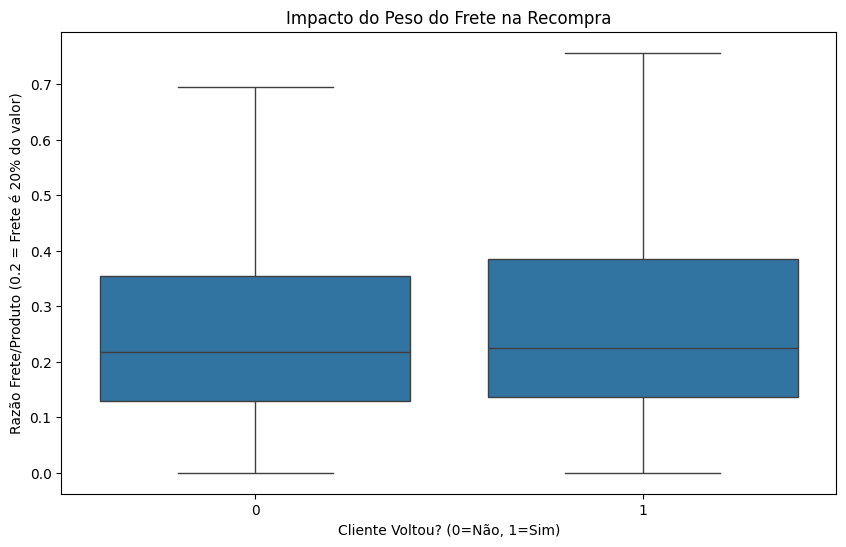

          count      mean       std  min       25%       50%       75%  \
voltou                                                                   
0       92431.0  0.307179  0.312118  0.0  0.131270  0.224100  0.378697   
1        2956.0  0.323881  0.311232  0.0  0.138501  0.232159  0.406377   

              max  
voltou             
0       21.447059  
1        5.005005  


In [74]:
# Precisamos trazer os valores (price e freight_value) dos itens
df_order_items = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_order_items_dataset.csv")

# Como um pedido pode ter vários itens, somamos os valores para ter o total do pedido
df_items_agrupado = df_order_items.groupby('order_id')[['price', 'freight_value']].sum().reset_index()

# Juntar com nossa base de análise
df_p1 = df_first_experience.merge(df_items_agrupado, on='order_id', how='left')

# Calcular a razão Frete / Preço
# Evitar divisão por zero (se price for 0, usamos np.nan)
df_p1['freight_ratio'] = df_p1['freight_value'] / df_p1['price'].replace(0, np.nan)

# Remover outliers extremos para visualização (frete > 2x o valor do produto é raro e distorce o gráfico)
df_p1_clean = df_p1[df_p1['freight_ratio'] <= 1.0] 

# Visualização
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_p1_clean, x='voltou', y='freight_ratio', showfliers=False)
plt.title("Impacto do Peso do Frete na Recompra")
plt.xlabel("Cliente Voltou? (0=Não, 1=Sim)")
plt.ylabel("Razão Frete/Produto (0.2 = Frete é 20% do valor)")
plt.show()

# Estatística descritiva
print(df_p1.groupby('voltou')['freight_ratio'].describe())

#### R: **Não há nenhuma evidencia de que o valor do frete influencia na volta de um cliente, neste caso, o frete é mais ou menos o mesmo para ambos**

## Certos produtos geram fidelidade?

/tmp/ipykernel_1019768/1032001588.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_categorias.head(10), x='taxa_pct', y='product_category_name', palette='Blues_d')
/tmp/ipykernel_1019768/1032001588.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_categorias.tail(10), x='taxa_pct', y='product_category_name', palette='Reds_d')


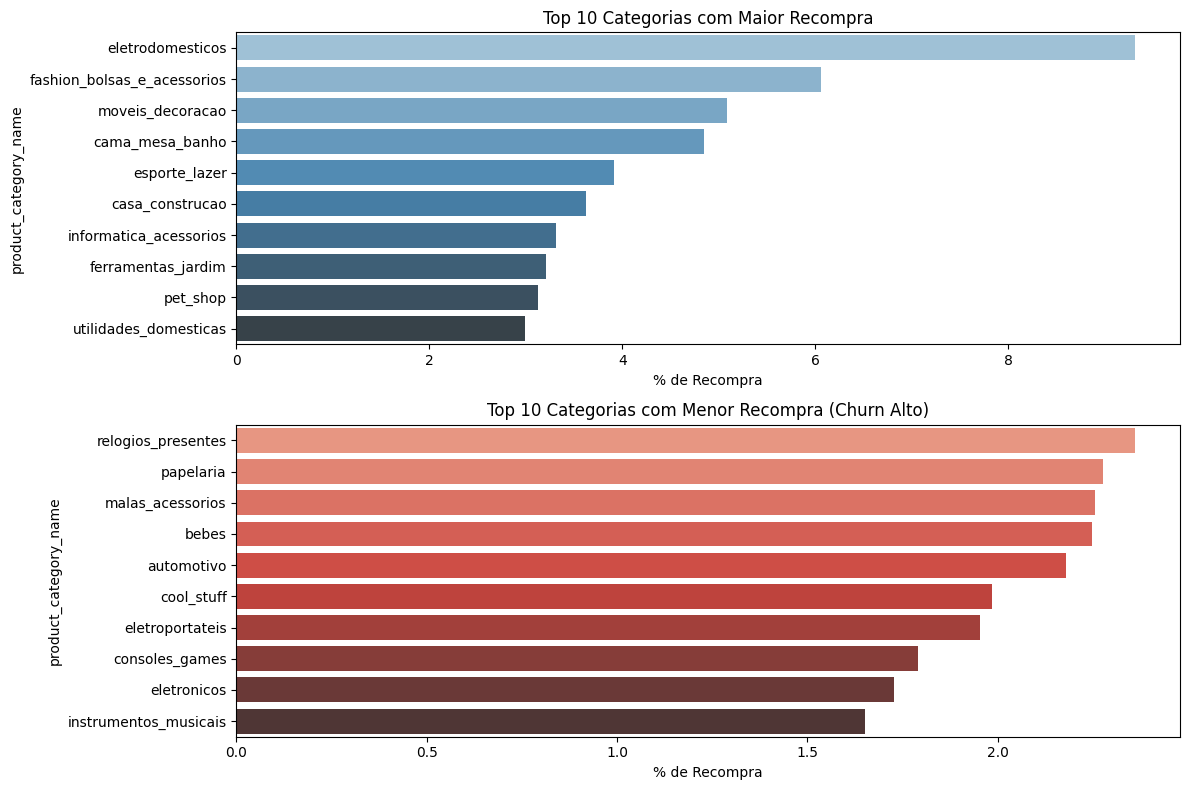

In [75]:
df_products = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_products_dataset.csv")

#  Juntar Pedido -> Item -> Produto
df_p4 = df_first_experience.merge(df_order_items[['order_id', 'product_id']], on='order_id', how='left')
df_p4 = df_p4.merge(df_products[['product_id', 'product_category_name']], on='product_id', how='left')

# Filtrar categorias com volume mínimo (ex: > 500 vendas) para evitar ruído estatístico
volume_categoria = df_p4['product_category_name'].value_counts()
categorias_validas = volume_categoria[volume_categoria > 500].index
df_p4_filtrado = df_p4[df_p4['product_category_name'].isin(categorias_validas)]

# Calcular % de recompra por categoria
rank_categorias = df_p4_filtrado.groupby('product_category_name')['voltou'].mean().sort_values(ascending=False).reset_index()
rank_categorias['taxa_pct'] = rank_categorias['voltou'] * 100

# Visualizar Top 10 e Bottom 10
plt.figure(figsize=(12, 8))

# Top 10 (Mais fiéis)
plt.subplot(2, 1, 1)
sns.barplot(data=rank_categorias.head(10), x='taxa_pct', y='product_category_name', palette='Blues_d')
plt.title("Top 10 Categorias com Maior Recompra")
plt.xlabel("% de Recompra")

# Bottom 10 (Menos fiéis)
plt.subplot(2, 1, 2)
sns.barplot(data=rank_categorias.tail(10), x='taxa_pct', y='product_category_name', palette='Reds_d')
plt.title("Top 10 Categorias com Menor Recompra (Churn Alto)")
plt.xlabel("% de Recompra")

plt.tight_layout()
plt.show()

## Um produto com menor % de recompra é necessaria pior avaliado?

In [76]:
df_order_reviews = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_order_reviews_dataset.csv")

# 1. Preparar os dados: Juntar Categoria, Recompra (Target) e Review Score
df_analise_completa = df_first_experience.merge(df_order_items, on='order_id', how='left')
df_analise_completa = df_analise_completa.merge(df_products, on='product_id', how='left')
df_analise_completa = df_analise_completa.merge(df_order_reviews, on='order_id', how='left')



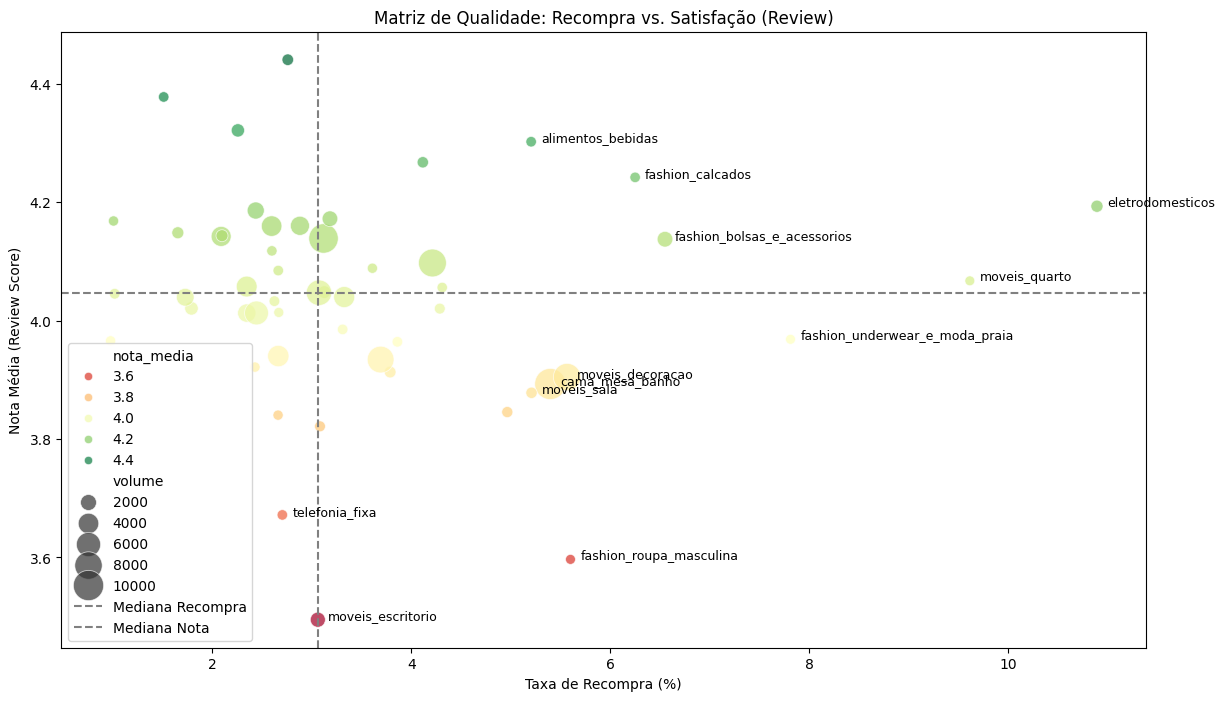

Top 5 Categorias 'Bens Duráveis' (Baixa Recompra, Alta Nota):
                 categoria  taxa_recompra  nota_media  volume  \
48  livros_interesse_geral       0.027574    4.440741     544   
49         livros_tecnicos       0.015094    4.377863     265   
50        malas_acessorios       0.022556    4.321395    1064   
59               papelaria       0.024351    4.186018    2464   
61                     pcs       0.010050    4.168367     199   

    taxa_recompra_pct  
48           2.757353  
49           1.509434  
50           2.255639  
59           2.435065  
61           1.005025  


In [77]:
diagnostico_produto = df_analise_completa.groupby('product_category_name').agg({
    'voltou': 'mean',          # Taxa de Recompra (0 a 1)
    'review_score': 'mean',    # Satisfação (1 a 5)
    'order_id': 'count'        # Volume (para filtrar pequenos)
}).reset_index()

# 2. Filtrar categorias relevantes (> 100 vendas)
diagnostico_produto = diagnostico_produto[diagnostico_produto['order_id'] > 100]

# Renomear para facilitar
diagnostico_produto.columns = ['categoria', 'taxa_recompra', 'nota_media', 'volume']
diagnostico_produto['taxa_recompra_pct'] = diagnostico_produto['taxa_recompra'] * 100

# 3. Visualização: O Scatter Plot (Mapa do Tesouro)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=diagnostico_produto, 
    x='taxa_recompra_pct', 
    y='nota_media', 
    size='volume',      # Tamanho da bolinha = Volume de vendas
    sizes=(50, 500),    # Escala das bolinhas
    alpha=0.7,
    hue='nota_media',   # Cor baseada na nota
    palette='RdYlGn'    # Vermelho (Ruim) a Verde (Bom)
)

# Adicionar linhas médias para criar os quadrantes
plt.axvline(diagnostico_produto['taxa_recompra_pct'].median(), color='grey', linestyle='--', label='Mediana Recompra')
plt.axhline(diagnostico_produto['nota_media'].median(), color='grey', linestyle='--', label='Mediana Nota')

# Adicionar labels nas categorias extremas para identificar (opcional)
# Loop para escrever o nome das categorias que estão nos extremos
for i in range(diagnostico_produto.shape[0]):
    row = diagnostico_produto.iloc[i]
    # Mostrar nome apenas se for muito discrepante (Muito alta/baixa recompra ou nota)
    if row['taxa_recompra_pct'] > 5.0 or row['nota_media'] < 3.8 or row['nota_media'] > 4.5:
        plt.text(row['taxa_recompra_pct']+0.1, row['nota_media'], row['categoria'], fontsize=9)

plt.title("Matriz de Qualidade: Recompra vs. Satisfação (Review)")
plt.xlabel("Taxa de Recompra (%)")
plt.ylabel("Nota Média (Review Score)")
plt.legend()
plt.show()

# 4. Tabela dos "Falsos Ruins" (Baixa Recompra mas Alta Nota)
print("Top 5 Categorias 'Bens Duráveis' (Baixa Recompra, Alta Nota):")
mask_duraveis = (diagnostico_produto['taxa_recompra_pct'] < diagnostico_produto['taxa_recompra_pct'].median()) & \
                (diagnostico_produto['nota_media'] > 4.0)
print(diagnostico_produto[mask_duraveis].sort_values('nota_media', ascending=False).head(5))

### R: **Podemos tirar de insight aqui que: 1. Não necessariamente produtos com baixa porcentagem de recompra tem uma nota ruim, 2. Para prever pontenciais clientes que possam voltar, categorizar os produtos com base nestes quadrantes dirá melhor ao modelo quais produtos realmente são bons além de outras features**

## Clientes que compraram de vendedores com baixo volume de vendas (amadores) têm menor taxa de retorno do que aqueles que compraram de "Vendedores Platinum"?

/tmp/ipykernel_1019768/1726675587.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


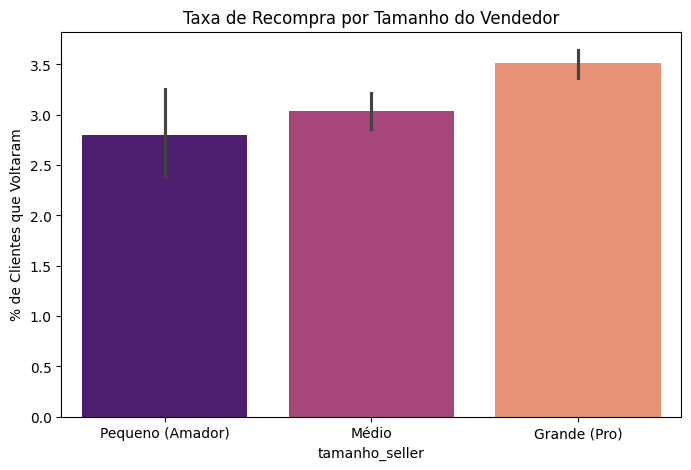

Total de Clientes Recorrentes: 2989
Compraram sempre do mesmo vendedor: 862
Taxa de Fidelidade ao Vendedor: 28.84%


In [78]:
# --- Análise de Sellers ---

new_costumer_orders = pd.merge(df_order_items, df_costumer_orders, on='order_id', how='left')

# Precisamos juntar Order -> Item -> Seller
df_seller_analysis = df_first_experience.merge(df_order_items[['order_id', 'seller_id']], on='order_id', how='left')

# 1. Classificar Vendedores por Tamanho (no momento da compra)

# Contamos quantas vendas o vendedor teve no total da base
vendas_por_seller = df_order_items.groupby('seller_id').size()
# Definimos "Pequeno" como < 10 vendas, "Médio" 10-100, "Grande" > 100
def classificar_seller(qtd):
    if qtd < 10: return 'Pequeno (Amador)'
    if qtd < 100: return 'Médio'
    return 'Grande (Pro)'

df_seller_analysis['tamanho_seller'] = df_seller_analysis['seller_id'].map(vendas_por_seller).apply(classificar_seller)

# 2. Visualizar Taxa de Recompra por Tamanho do Vendedor
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_seller_analysis, 
    x='tamanho_seller', 
    y='voltou', 
    order=['Pequeno (Amador)', 'Médio', 'Grande (Pro)'],
    estimator=lambda x: np.mean(x)*100,
    palette='magma'
)
plt.title("Taxa de Recompra por Tamanho do Vendedor")
plt.ylabel("% de Clientes que Voltaram")
plt.show()

# 3. Investigar se quem volta, volta para o mesmo seller
# (Análise apenas para os recorrentes)
clientes_recorrentes = new_costumer_orders[new_costumer_orders['customer_unique_id'].isin(ids_recorrentes)]
# Agrupar e contar vendedores únicos por cliente
fidelity_seller = clientes_recorrentes.groupby('customer_unique_id')['seller_id'].nunique()

print(f"Total de Clientes Recorrentes: {len(fidelity_seller)}")
print(f"Compraram sempre do mesmo vendedor: {sum(fidelity_seller == 1)}")
print(f"Taxa de Fidelidade ao Vendedor: {sum(fidelity_seller == 1) / len(fidelity_seller):.2%}")

### R: **Os dados mostram que o tamanho do seller impacta na retenção deste, e também aponta que usuarios não tem fidelidade a um vendedor em si, isso significa que na criação do modelo, não prestaremos atenção a quem vende, mas sim o tipo do vendedor**

## Clientes de regiões mais distantes do centro logístico ou que realizaram compra um estado diferente ao do vendedor realizaram uma recompra?

/tmp/ipykernel_1019768/3113822156.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_estado_pct.index, y=taxa_estado_pct.values, palette='coolwarm')


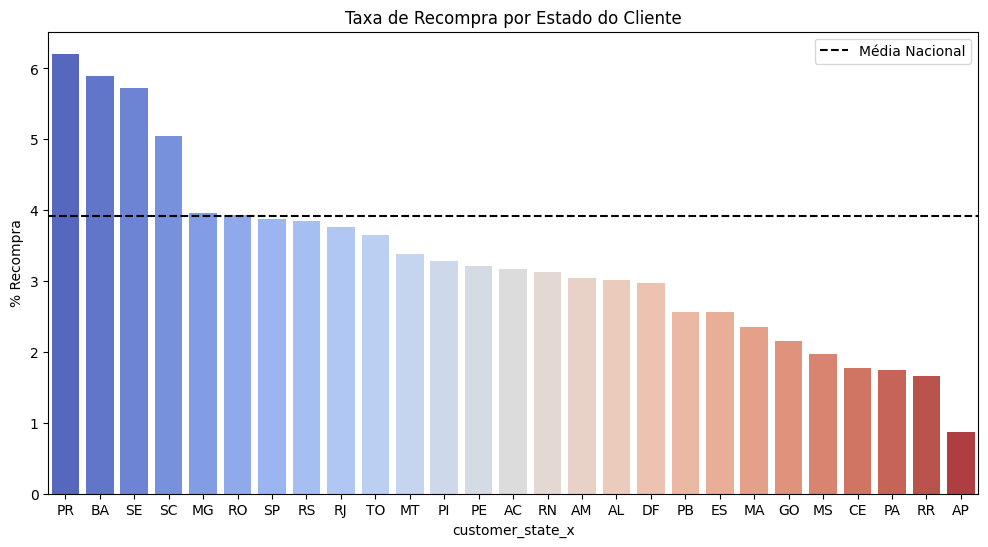

Taxa de Recompra por Tipo de Rota:
                  mean  count
mesmo_estado                 
False         0.038976  96033
True          0.039439  55630


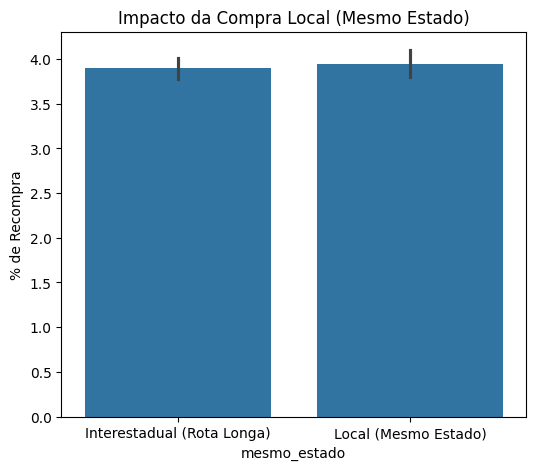

In [82]:
# --- Análise de Geolocalização ---
# Precisamos das tabelas: Customers (para pegar o estado do cliente) e Sellers (para o estado do vendedor)

df_customers = new_costumer_orders.copy()
df_sellers = pd.read_csv(r"/home/zacc-marc/Desktop/Zacc Workspace/churn_prediction_model/olist-churn-prediction/data/raw/olist_sellers_dataset.csv")

# Juntar Customer State na nossa base de análise
df_geo = df_first_experience.merge(df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
# Juntar Seller State
df_geo = df_geo.merge(df_order_items[['order_id', 'seller_id']], on='order_id', how='left')
df_geo = df_geo.merge(df_sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

# 1. Recompra por Estado do Cliente (Mapa de Calor Lógico)
taxa_estado = df_geo.groupby('customer_state_x')['voltou'].mean().sort_values(ascending=False)
taxa_estado_pct = taxa_estado * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=taxa_estado_pct.index, y=taxa_estado_pct.values, palette='coolwarm')
plt.title("Taxa de Recompra por Estado do Cliente")
plt.ylabel("% Recompra")
plt.axhline(df_geo['voltou'].mean()*100, color='k', linestyle='--', label='Média Nacional')
plt.legend()
plt.show()

# 2. Rota "Local" vs "Interestadual"
df_geo['mesmo_estado'] = df_geo['customer_state_x'] == df_geo['seller_state']

print("Taxa de Recompra por Tipo de Rota:")
print(df_geo.groupby('mesmo_estado')['voltou'].agg(['mean', 'count']))

# Visualização
plt.figure(figsize=(6, 5))
sns.barplot(data=df_geo, x='mesmo_estado', y='voltou', estimator=lambda x: np.mean(x)*100)
plt.title("Impacto da Compra Local (Mesmo Estado)")
plt.xticks([0, 1], ['Interestadual (Rota Longa)', 'Local (Mesmo Estado)'])
plt.ylabel("% de Recompra")
plt.show()

### R: **Os dados mostram que não a distancia em si influencia na recompra, mas sim o estado em que ela ocorre**